**Redrob AI INDIA RUNS Hackathon**

**Notebook 1**: Dataset Forensics & Problem Understanding

**Objective**: Understand the dataset deeply before designing the ranking architecture.

Imports

In [1]:
import os
import json
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

plt.rcParams["figure.figsize"] = (10,5)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Dataset Paths

In [2]:
DATA_DIR = "/kaggle/input/datasets/parmindersingh2002/redrob-ai-india-runs-hackathon-dataset"

CANDIDATES_FILE = os.path.join(DATA_DIR, "candidates.jsonl")
SCHEMA_FILE = os.path.join(DATA_DIR, "candidate_schema.json")
SAMPLE_FILE = os.path.join(DATA_DIR, "sample_candidates.json")

Verify Files

In [3]:
for file in os.listdir(DATA_DIR):
    print(file)

sample_submission.csv
job_description.docx
submission_spec.docx
submission_metadata_template.yaml
redrob_signals_doc.docx
candidates.jsonl
sample_candidates.json
candidate_schema.json
validate_submission.py
README.docx


Load Schema

In [4]:
with open(SCHEMA_FILE) as f:
    schema = json.load(f)

print(schema.keys())

dict_keys(['$schema', 'title', 'description', 'type', 'required', 'properties'])


Stream Through Dataset (Fast)

In [5]:
candidate_count = 0

sample_candidates = []

with open(CANDIDATES_FILE) as f:

    for line in tqdm(f):

        obj = json.loads(line)

        candidate_count += 1

        if len(sample_candidates) < 10:
            sample_candidates.append(obj)

print(f"Candidates: {candidate_count:,}")

0it [00:00, ?it/s]

Candidates: 100,000


Random Candidate Inspection

In [6]:
random_candidate = random.choice(sample_candidates)
random_candidate

{'candidate_id': 'CAND_0000002',
 'profile': {'anonymized_name': 'Saanvi Sethi',
  'headline': 'Operations Manager | 12.5+ yrs experience',
  'summary': "Professional with 12.5+ years of experience. My professional background is in marketing manager — I've built and led teams, owned KPIs, and driven business outcomes in this domain. Lately I've been curious about how AI tools could augment my work — I've experimented with ChatGPT and a few other tools for productivity and content creation, and I think the space is exciting. Open to roles where I can apply my domain expertise alongside emerging AI capabilities.",
  'location': 'Chennai, Tamil Nadu',
  'country': 'India',
  'years_of_experience': 12.5,
  'current_title': 'Operations Manager',
  'current_company': 'Wipro',
  'current_company_size': '10001+',
  'current_industry': 'IT Services'},
 'career_history': [{'company': 'Wipro',
   'title': 'Operations Manager',
   'start_date': '2022-11-14',
   'end_date': None,
   'duration_month

Dataset Integrity

In [7]:
candidate_ids = set()

duplicates = 0

with open(CANDIDATES_FILE) as f:

    for line in tqdm(f):

        obj = json.loads(line)

        cid = obj["candidate_id"]

        if cid in candidate_ids:
            duplicates += 1

        candidate_ids.add(cid)

print("Duplicate IDs:", duplicates)

0it [00:00, ?it/s]

Duplicate IDs: 0


High-Level Statistics

In [8]:
stats = defaultdict(list)

with open(CANDIDATES_FILE) as f:

    for line in tqdm(f):

        c = json.loads(line)

        stats["experience"].append(
            c["profile"]["years_of_experience"]
        )

        stats["num_jobs"].append(
            len(c["career_history"])
        )

        stats["num_skills"].append(
            len(c["skills"])
        )

        stats["num_education"].append(
            len(c["education"])
        )

        stats["num_certifications"].append(
            len(c.get("certifications", []))
        )

0it [00:00, ?it/s]

Summary Table

In [9]:
summary = pd.DataFrame({

    "Experience": pd.Series(stats["experience"]),

    "Jobs": pd.Series(stats["num_jobs"]),

    "Skills": pd.Series(stats["num_skills"]),

    "Education": pd.Series(stats["num_education"]),

    "Certifications": pd.Series(stats["num_certifications"])

})

summary.describe().T

,count,mean,std,min,25%,50%,75%,max
Experience,100000.0,7.166319,3.824551,1.0,3.9,6.8,9.9,16.9
Jobs,100000.0,3.001710,1.522442,1.0,2.0,3.0,4.0,9.0
Skills,100000.0,9.603020,3.311630,5.0,7.0,9.0,11.0,23.0
Education,100000.0,1.397780,0.489442,1.0,1.0,1.0,2.0,2.0
Certifications,100000.0,0.374840,0.696046,0.0,0.0,0.0,0.0,3.0


Distribution Plots

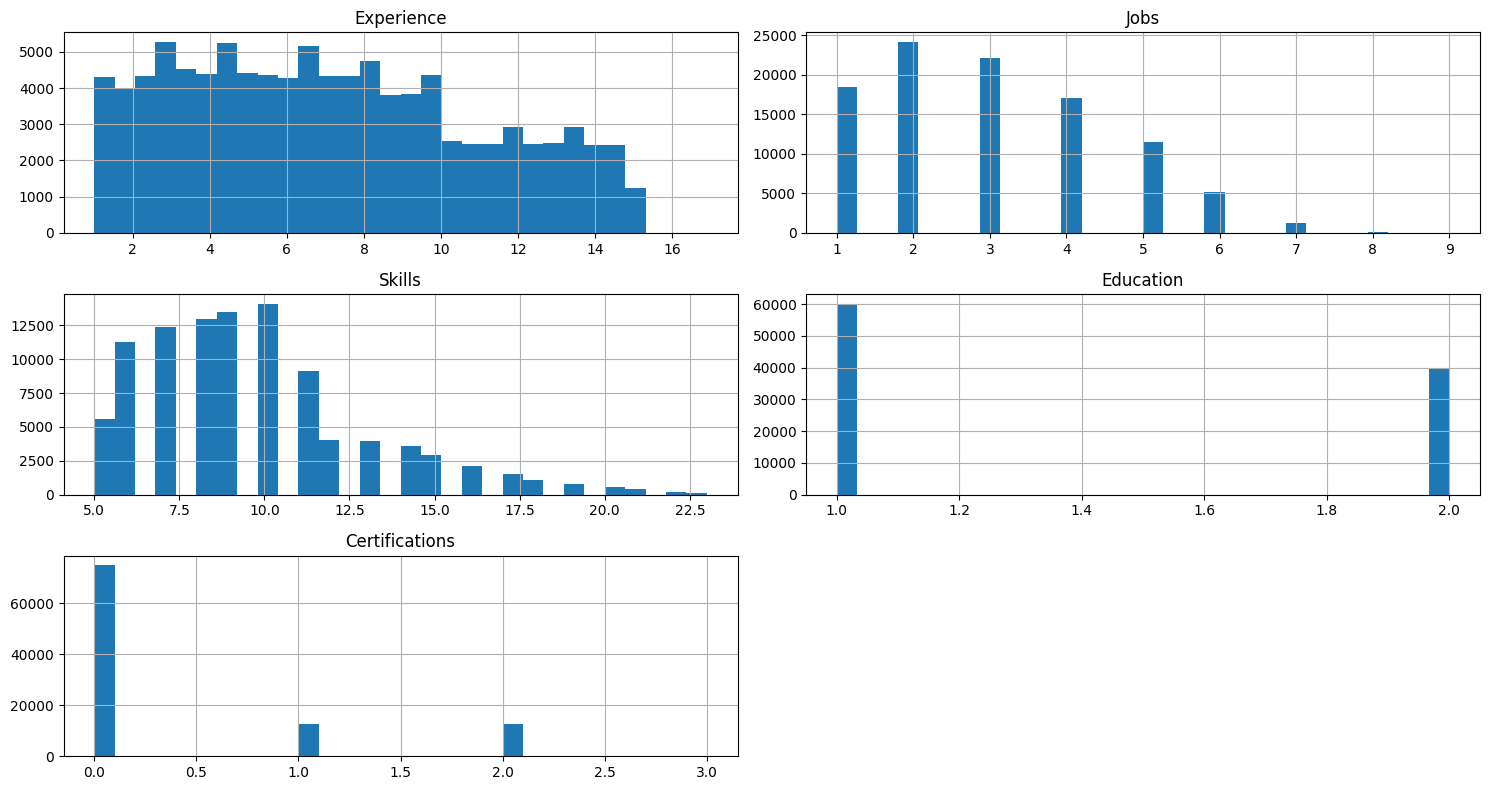

In [10]:
summary.hist(
    bins=30,
    figsize=(15,8)
)

plt.tight_layout()
plt.show()

Candidate Profile Inventory

In [11]:
profile_titles = Counter()
industries = Counter()
company_sizes = Counter()
countries = Counter()

with open(CANDIDATES_FILE) as f:

    for line in tqdm(f):

        c = json.loads(line)

        p = c["profile"]

        profile_titles[p["current_title"]] += 1
        industries[p["current_industry"]] += 1
        company_sizes[p["current_company_size"]] += 1
        countries[p["country"]] += 1

0it [00:00, ?it/s]

Top Current Titles

In [12]:
pd.DataFrame(

    profile_titles.most_common(30),

    columns=["Title","Count"]

)

,Title,Count
0,Business Analyst,5833
1,HR Manager,5830
2,Mechanical Engineer,5791
3,Accountant,5764
4,Project Manager,5754
5,Customer Support,5750
6,Operations Manager,5744
7,Content Writer,5727
8,Sales Executive,5713
9,Civil Engineer,5702


Top Industries

In [13]:
pd.DataFrame(

    industries.most_common(25),

    columns=["Industry","Count"]

)

,Industry,Count
0,IT Services,29881
1,Software,22417
2,Manufacturing,22305
3,Conglomerate,7571
4,Paper Products,7467
5,Fintech,2808
6,Food Delivery,2514
7,E-commerce,1529
8,Consulting,1274
9,EdTech,610


Define AI Keywords

In [14]:
AI_KEYWORDS = {
    # Core AI
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "generative ai",
    "genai",
    "llm",
    "nlp",
    "computer vision",
    "recommendation",
    "recommender",
    "ranking",
    "retrieval",
    "rag",
    "embedding",
    "embeddings",
    "semantic search",

    # Frameworks
    "tensorflow",
    "pytorch",
    "keras",
    "scikit-learn",
    "xgboost",
    "lightgbm",
    "transformers",

    # LLM ecosystem
    "langchain",
    "llamaindex",
    "huggingface",

    # Vector DB
    "faiss",
    "pinecone",
    "weaviate",
    "qdrant",
    "milvus",

    # Search
    "elasticsearch",
    "opensearch",

    # MLOps
    "mlops",
    "airflow",
    "kubeflow",

    # Languages
    "python",

    # Cloud
    "aws",
    "azure",
    "gcp"
}

Helper Function

In [15]:
def contains_ai_keywords(text):

    if text is None:
        return set()

    text = str(text).lower()

    found = set()

    for keyword in AI_KEYWORDS:
        if keyword in text:
            found.add(keyword)

    return found

Candidate AI Coverage

In [16]:
from collections import Counter

keyword_counter = Counter()

candidate_ai_matches = []

with open(CANDIDATES_FILE) as f:

    for line in tqdm(f):

        c = json.loads(line)

        matched = set()

        profile = c["profile"]

        matched |= contains_ai_keywords(profile["headline"])
        matched |= contains_ai_keywords(profile["summary"])
        matched |= contains_ai_keywords(profile["current_title"])

        # Career history

        for job in c["career_history"]:

            matched |= contains_ai_keywords(job["title"])
            matched |= contains_ai_keywords(job["description"])

        # Skills

        for skill in c["skills"]:

            matched |= contains_ai_keywords(skill["name"])

        if matched:

            candidate_ai_matches.append({

                "candidate_id": c["candidate_id"],

                "experience": profile["years_of_experience"],

                "title": profile["current_title"],

                "industry": profile["current_industry"],

                "num_keywords": len(matched),

                "keywords": sorted(list(matched))
            })

        keyword_counter.update(matched)

0it [00:00, ?it/s]

Overall Coverage

In [17]:
print("Candidates mentioning at least one AI keyword:")

print(len(candidate_ai_matches))

print()

print(f"Coverage: {100*len(candidate_ai_matches)/candidate_count:.2f}%")

Candidates mentioning at least one AI keyword:
83367

Coverage: 83.37%


Top Technologies

In [18]:
pd.DataFrame(

    keyword_counter.most_common(),

    columns=["Keyword","Count"]

)

,Keyword,Count
0,llm,41965
1,rag,35785
2,aws,19566
3,airflow,16628
4,python,12864
5,gcp,11983
6,azure,11828
7,transformers,7659
8,langchain,6896
9,retrieval,5800


AI Candidate DataFrame

In [19]:
ai_df = pd.DataFrame(candidate_ai_matches)

ai_df.head()

,candidate_id,experience,title,industry,num_keywords,keywords
0,CAND_0000001,6.9,Backend Engineer,IT Services,8,"[airflow, aws, gcp, llm, milvus, nlp, python, rag]"
1,CAND_0000002,12.5,Operations Manager,IT Services,2,"[gcp, llm]"
2,CAND_0000004,3.8,Marketing Manager,Paper Products,2,"[airflow, llm]"
3,CAND_0000010,4.6,Data Engineer,Transportation,9,"[airflow, azure, elasticsearch, gcp, kubeflow, mlops, python, rag, xgboost]"
4,CAND_0000011,2.0,QA Engineer,Software,6,"[aws, azure, kubeflow, rag, recommendation, transformers]"


Distribution

In [20]:
ai_df.describe()

,experience,num_keywords
count,83367.000000,83367.000000
mean,7.288078,2.966318
std,3.800134,2.866654
min,1.000000,1.000000
25%,4.100000,1.000000
50%,7.000000,2.000000
75%,10.000000,3.000000
max,16.900000,23.000000


Current Titles

In [21]:
ai_df["title"].value_counts().head(40)

title
Business Analyst                   4461
Operations Manager                 4423
Sales Executive                    4390
Customer Support                   4377
Mechanical Engineer                4367
HR Manager                         4361
Accountant                         4348
Project Manager                    4334
Civil Engineer                     4313
Graphic Designer                   4300
Content Writer                     4277
Marketing Manager                  4237
Software Engineer                  3450
Full Stack Developer               2873
Cloud Engineer                     2836
Java Developer                     2809
.NET Developer                     2788
DevOps Engineer                    2787
Mobile Developer                   2757
Frontend Engineer                  2738
QA Engineer                        2682
Analytics Engineer                  764
Data Engineer                       744
Data Analyst                        728
Backend Engineer                  

Industries

In [22]:
ai_df["industry"].value_counts().head(30)

industry
IT Services             25293
Software                17870
Manufacturing           17859
Conglomerate             6048
Paper Products           5938
Fintech                  2808
Food Delivery            2514
E-commerce               1529
Consulting               1274
EdTech                    610
SaaS                      328
AI/ML                     278
AdTech                    172
Transportation            162
Insurance Tech            155
Gaming                    149
HealthTech                147
HealthTech AI              68
Conversational AI          62
AI Services                42
Voice AI                   31
Internet                   22
Media                       6
Consumer Electronics        2
Name: count, dtype: int64

Strongest AI Candidates

In [23]:
ai_df.sort_values(

    "num_keywords",

    ascending=False

).head(25)

,candidate_id,experience,title,industry,num_keywords,keywords
33110,CAND_0039754,16.2,Senior Applied Scientist,Internet,23,"[deep learning, elasticsearch, embedding, embeddings, faiss, kubeflow, llamaindex, llm, machine learning, nlp, opensearch, pinecone, python, qdran..."
37400,CAND_0044883,6.3,AI Engineer,AI/ML,22,"[computer vision, deep learning, elasticsearch, embedding, embeddings, faiss, kubeflow, lightgbm, llm, machine learning, nlp, pinecone, pytorch, r..."
4677,CAND_0005649,7.4,Senior Data Scientist,AI/ML,21,"[deep learning, elasticsearch, embedding, embeddings, faiss, kubeflow, lightgbm, llm, machine learning, nlp, pinecone, rag, ranking, recommendatio..."
17335,CAND_0020877,5.1,Applied ML Engineer,Fintech,21,"[deep learning, elasticsearch, embedding, embeddings, faiss, kubeflow, llamaindex, machine learning, milvus, nlp, opensearch, pinecone, pytorch, q..."
1322,CAND_0001610,3.0,Machine Learning Engineer,Gaming,21,"[computer vision, deep learning, elasticsearch, embedding, embeddings, faiss, kubeflow, lightgbm, llm, machine learning, milvus, nlp, pinecone, py..."
25773,CAND_0030953,7.8,Search Engineer,E-commerce,20,"[elasticsearch, embedding, embeddings, faiss, langchain, lightgbm, machine learning, mlops, nlp, pinecone, python, qdrant, rag, ranking, recommend..."
11121,CAND_0013393,5.3,ML Engineer,SaaS,20,"[computer vision, embedding, embeddings, llm, machine learning, milvus, mlops, nlp, opensearch, pinecone, python, pytorch, qdrant, ranking, recomm..."
28198,CAND_0033861,8.0,Senior NLP Engineer,AI/ML,20,"[elasticsearch, embedding, embeddings, kubeflow, llamaindex, llm, machine learning, milvus, nlp, pinecone, qdrant, rag, ranking, recommendation, r..."
21988,CAND_0026424,5.6,Senior Software Engineer (ML),Fintech,19,"[computer vision, embedding, embeddings, kubeflow, lightgbm, llamaindex, llm, machine learning, mlops, nlp, pinecone, python, pytorch, ranking, re..."
35021,CAND_0042029,6.5,Senior Data Scientist,E-commerce,19,"[deep learning, elasticsearch, embedding, embeddings, faiss, lightgbm, machine learning, nlp, opensearch, pinecone, pytorch, rag, ranking, recomme..."


Manual Inspection

In [24]:
top_ids = ai_df.sort_values(

    "num_keywords",

    ascending=False

).head(5)["candidate_id"]

top_ids = set(top_ids)

with open(CANDIDATES_FILE) as f:

    for line in f:

        c = json.loads(line)

        if c["candidate_id"] in top_ids:

            print("="*80)

            print(c["candidate_id"])

            print()

            print(json.dumps(c, indent=2))

            print()

CAND_0001610

{
  "candidate_id": "CAND_0001610",
  "profile": {
    "anonymized_name": "Aryan Banerjee",
    "headline": "Machine Learning Engineer | Applied ML | Building intelligent products",
    "summary": "Machine learning engineer with 5.2 years of experience building ML-powered features in production. Strong background in NLP, recommendation systems, and applied AI; comfortable across the ML stack from feature engineering through deployment. Recently, I built our semantic search infrastructure from scratch \u2014 sentence-transformers, FAISS, the works. I've spent enough time debugging production ranking issues to know which signals matter and which are noise. My academic background is in CS/ML but my main learning has come from shipping real systems and seeing what holds up under production load. Open to senior IC roles in applied ML or AI engineering, ideally at product companies where I'd own a meaningful piece of the ML stack.",
    "location": "Trivandrum, Kerala",
    "co

In [25]:
signal_rows = []

with open(CANDIDATES_FILE) as f:

    for line in tqdm(f):

        c = json.loads(line)

        s = c["redrob_signals"]

        row = {}

        row["profile_completeness"] = s["profile_completeness_score"]

        row["views"] = s["profile_views_received_30d"]

        row["applications"] = s["applications_submitted_30d"]

        row["response_rate"] = s["recruiter_response_rate"]

        row["response_time"] = s["avg_response_time_hours"]

        row["connections"] = s["connection_count"]

        row["endorsements"] = s["endorsements_received"]

        row["notice_period"] = s["notice_period_days"]

        row["github"] = s["github_activity_score"]

        row["search_appearance"] = s["search_appearance_30d"]

        row["saved"] = s["saved_by_recruiters_30d"]

        row["interview"] = s["interview_completion_rate"]

        row["offer_accept"] = s["offer_acceptance_rate"]

        row["open_to_work"] = s["open_to_work_flag"]

        row["verified_email"] = s["verified_email"]

        row["verified_phone"] = s["verified_phone"]

        row["linkedin"] = s["linkedin_connected"]

        signal_rows.append(row)

signals = pd.DataFrame(signal_rows)

0it [00:00, ?it/s]

In [26]:
signals.describe().T

,count,mean,std,min,25%,50%,75%,max
profile_completeness,100000.0,56.758180,17.274069,25.00,42.20,56.80,71.60,99.90
views,100000.0,47.985250,32.051870,0.00,23.00,45.00,68.00,374.00
applications,100000.0,5.390360,3.494796,0.00,2.00,5.00,8.00,24.00
response_rate,100000.0,0.436574,0.214122,0.02,0.25,0.44,0.62,0.95
response_time,100000.0,132.702744,75.238241,2.10,68.30,129.90,193.30,280.00
connections,100000.0,345.664890,208.145694,10.00,174.00,335.00,497.00,1898.00
endorsements,100000.0,30.068570,20.242847,0.00,14.00,28.00,43.00,242.00
notice_period,100000.0,87.385800,36.589628,0.00,60.00,90.00,120.00,150.00
github,100000.0,9.619230,17.761394,-1.00,-1.00,-1.00,16.70,96.90
search_appearance,100000.0,117.543800,92.825891,0.00,52.00,105.00,158.00,1490.00


In [27]:
signals.isna().sum().sort_values(ascending=False)

profile_completeness    0
views                   0
applications            0
response_rate           0
response_time           0
connections             0
endorsements            0
notice_period           0
github                  0
search_appearance       0
saved                   0
interview               0
offer_accept            0
open_to_work            0
verified_email          0
verified_phone          0
linkedin                0
dtype: int64

In [28]:
for col in signals.columns:

    if signals[col].dtype != object:

        print(col)

        print((signals[col] == -1).sum())

        print()

profile_completeness
0

views
0

applications
0

response_rate
0

response_time
0

connections
0

endorsements
0

notice_period
0

github
64637

search_appearance
0

saved
0

interview
0

offer_accept
59554

open_to_work
0

verified_email
0

verified_phone
0

linkedin
0



In [29]:
corr = signals.select_dtypes(include=np.number).corr()

corr

,profile_completeness,views,applications,response_rate,response_time,connections,endorsements,notice_period,github,search_appearance,saved,interview,offer_accept
profile_completeness,1.000000,0.071795,0.039234,0.023116,-0.043147,0.062900,0.078141,0.002038,0.043333,0.110880,0.097179,0.041293,0.028706
views,0.071795,1.000000,0.095536,0.067679,-0.101489,0.148552,0.184175,0.007002,0.118936,0.250472,0.228996,0.108539,0.077969
applications,0.039234,0.095536,1.000000,0.033038,-0.052731,0.068044,0.098553,0.006949,0.056246,0.118928,0.105397,0.049372,0.036756
response_rate,0.023116,0.067679,0.033038,1.000000,-0.037826,0.053721,0.063618,0.003748,0.042130,0.084197,0.084060,0.036047,0.031776
response_time,-0.043147,-0.101489,-0.052731,-0.037826,1.000000,-0.084809,-0.105660,-0.007223,-0.068122,-0.137599,-0.127828,-0.062315,-0.047238
connections,0.062900,0.148552,0.068044,0.053721,-0.084809,1.000000,0.155024,0.008049,0.093767,0.204520,0.180022,0.080879,0.061799
endorsements,0.078141,0.184175,0.098553,0.063618,-0.105660,0.155024,1.000000,0.005688,0.123682,0.262825,0.233320,0.107725,0.079502
notice_period,0.002038,0.007002,0.006949,0.003748,-0.007223,0.008049,0.005688,1.000000,0.004647,-0.002826,0.002264,0.013351,0.004827
github,0.043333,0.118936,0.056246,0.042130,-0.068122,0.093767,0.123682,0.004647,1.000000,0.162759,0.147717,0.074231,0.047522
search_appearance,0.110880,0.250472,0.118928,0.084197,-0.137599,0.204520,0.262825,-0.002826,0.162759,1.000000,0.314029,0.139394,0.101981


In [30]:
corr.style.background_gradient(cmap="coolwarm")

,profile_completeness,views,applications,response_rate,response_time,connections,endorsements,notice_period,github,search_appearance,saved,interview,offer_accept
profile_completeness,1.000000,0.071795,0.039234,0.023116,-0.043147,0.062900,0.078141,0.002038,0.043333,0.110880,0.097179,0.041293,0.028706
views,0.071795,1.000000,0.095536,0.067679,-0.101489,0.148552,0.184175,0.007002,0.118936,0.250472,0.228996,0.108539,0.077969
applications,0.039234,0.095536,1.000000,0.033038,-0.052731,0.068044,0.098553,0.006949,0.056246,0.118928,0.105397,0.049372,0.036756
response_rate,0.023116,0.067679,0.033038,1.000000,-0.037826,0.053721,0.063618,0.003748,0.042130,0.084197,0.084060,0.036047,0.031776
response_time,-0.043147,-0.101489,-0.052731,-0.037826,1.000000,-0.084809,-0.105660,-0.007223,-0.068122,-0.137599,-0.127828,-0.062315,-0.047238
connections,0.062900,0.148552,0.068044,0.053721,-0.084809,1.000000,0.155024,0.008049,0.093767,0.204520,0.180022,0.080879,0.061799
endorsements,0.078141,0.184175,0.098553,0.063618,-0.105660,0.155024,1.000000,0.005688,0.123682,0.262825,0.233320,0.107725,0.079502
notice_period,0.002038,0.007002,0.006949,0.003748,-0.007223,0.008049,0.005688,1.000000,0.004647,-0.002826,0.002264,0.013351,0.004827
github,0.043333,0.118936,0.056246,0.042130,-0.068122,0.093767,0.123682,0.004647,1.000000,0.162759,0.147717,0.074231,0.047522
search_appearance,0.110880,0.250472,0.118928,0.084197,-0.137599,0.204520,0.262825,-0.002826,0.162759,1.000000,0.314029,0.139394,0.101981


In [31]:
all_skills = Counter()

skill_proficiency = Counter()

skill_duration = defaultdict(list)

with open(CANDIDATES_FILE) as f:

    for line in tqdm(f):

        c = json.loads(line)

        for skill in c["skills"]:

            name = skill["name"].strip()

            all_skills[name] += 1

            skill_proficiency[skill["proficiency"]] += 1

            skill_duration[name].append(
                skill["duration_months"]
            )

0it [00:00, ?it/s]

In [32]:
print("Unique Skills:", len(all_skills))

Unique Skills: 133


In [33]:
pd.DataFrame(

    all_skills.most_common(100),

    columns=["Skill","Count"]

)

,Skill,Count
0,HTML,12246
1,Databricks,12244
2,Redux,12222
3,Terraform,12187
4,Angular,12173
...,...,...
95,Weights & Biases,4685
96,Forecasting,4676
97,TTS,4669
98,Statistical Modeling,4634


In [34]:
pd.DataFrame(

    skill_proficiency.items(),

    columns=["Level","Count"]

)

,Level,Count
0,intermediate,470309
1,advanced,109585
2,beginner,379097
3,expert,1311


In [35]:
skill_duration_df = pd.DataFrame({

    "skill": list(skill_duration.keys()),

    "avg_duration":

        [

            np.mean(v)

            for v in skill_duration.values()

        ],

    "count":

        [

            len(v)

            for v in skill_duration.values()

        ]

})

skill_duration_df.sort_values(

    "count",

    ascending=False

).head(50)

,skill,avg_duration,count
53,HTML,16.122734,12246
29,Databricks,15.999673,12244
32,Redux,16.072820,12222
45,Terraform,15.914581,12187
24,Angular,15.963115,12173
85,Salesforce CRM,16.120507,12157
59,Figma,16.108991,12157
71,Vue.js,15.914594,12142
42,Sales,16.120448,12138
27,Accounting,16.117502,12136
